In [1]:
import pandas as pd
df=pd.read_csv('/workspaces/BlizzardX/Data/cleaned_data.csv')

In [2]:
import sys
sys.path.append('/workspaces/BlizzardX')

In [3]:
from src.Model.feature_engineering import FeatureEngineering , ColdEventDetector
fe=FeatureEngineering(df)
ce =ColdEventDetector(fe.apply_all_features())

In [4]:
df=ce.apply_cold_event_detection()

In [5]:
df[(df['Cold_Event'] == 1) & (df['Season']=='Winter')][['Station_ID', 'Cold_Event', 'TMIN', 'Rolling_10thPercentile_TMIN_7', 'Season','DATE','TMIN_Rolling_30_Diff']]

,Station_ID,Cold_Event,TMIN,Rolling_10thPercentile_TMIN_7,Season,DATE,TMIN_Rolling_30_Diff
158,USC00272302,1,-8.9,-7.58,Winter,2008-12-06,-3.73
160,USC00272302,1,-13.3,-10.66,Winter,2008-12-08,-6.96
161,USC00272302,1,-13.9,-13.54,Winter,2008-12-09,-5.41
172,USC00272302,1,-12.2,-10.88,Winter,2008-12-20,-5.06
173,USC00272302,1,-12.2,-12.20,Winter,2008-12-21,-4.74
...,...,...,...,...,...,...,...
97326,USW00014755,1,-29.4,-27.42,Winter,2025-01-30,-6.63
97327,USW00014755,1,-30.0,-29.64,Winter,2025-01-31,-5.89
97343,USW00014755,1,-25.0,-23.98,Winter,2025-02-17,-3.49
97344,USW00014755,1,-27.8,-26.12,Winter,2025-02-18,-5.01


In [6]:
df.to_csv('/workspaces/BlizzardX/Data/Final_Processed.csv', index=False)  # Save the processed DataFrame

In [ ]:
import pandas as pd
# Read the processed DataFrame

In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df=pd.read_csv('/workspaces/BlizzardX/Data/Final_Processed.csv', parse_dates=['DATE'])  
# Select necessary columns
features = ['DATE', 'Station_ID', 'TMIN', 'Rolling_Mean_TMIN_7', 'Rolling_10thPercentile_TMIN_7',
            'Seasonal_TMIN_Anomaly', 'EWMA_TMIN_7', 'TMIN_Lag1', 'TMIN_Rolling_30_Diff']

df = df[features]


In [3]:

# Choose a single station (Example: first unique station)
station_id = df['Station_ID'].unique()[0]
station_df = df[df['Station_ID'] == station_id].copy()

# Set the DATE as the index
station_df.set_index('DATE', inplace=True)




In [4]:
# Remove duplicate dates for the same station
station_df = station_df[~station_df.index.duplicated(keep='first')]

# Set daily frequency
station_df = station_df.asfreq('D')



In [5]:
station_df.isnull().sum()


Station_ID                       1
TMIN                             1
Rolling_Mean_TMIN_7              1
Rolling_10thPercentile_TMIN_7    1
Seasonal_TMIN_Anomaly            1
EWMA_TMIN_7                      1
TMIN_Lag1                        1
TMIN_Rolling_30_Diff             1
dtype: int64

In [6]:
station_df[station_df.isnull().any(axis=1)].head(10)

,Station_ID,TMIN,Rolling_Mean_TMIN_7,Rolling_10thPercentile_TMIN_7,Seasonal_TMIN_Anomaly,EWMA_TMIN_7,TMIN_Lag1,TMIN_Rolling_30_Diff
DATE,,,,,,,,
2025-02-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Preserve Station_ID and fill other columns
station_df['Station_ID'] = station_df['Station_ID'].ffill().bfill()

# Apply filling and interpolation to all other columns
station_df.loc[:, station_df.columns != 'Station_ID'] = (
    station_df.loc[:, station_df.columns != 'Station_ID']
    .infer_objects(copy=False)
    .apply(pd.to_numeric, errors='coerce')
    .ffill()
    .bfill()
    .interpolate(method='linear')
    .round(2)
)


In [8]:
station_df.columns

Index(['Station_ID', 'TMIN', 'Rolling_Mean_TMIN_7',
       'Rolling_10thPercentile_TMIN_7', 'Seasonal_TMIN_Anomaly', 'EWMA_TMIN_7',
       'TMIN_Lag1', 'TMIN_Rolling_30_Diff'],
      dtype='object')

17:50:53 - cmdstanpy - INFO - Chain [1] start processing
17:50:54 - cmdstanpy - INFO - Chain [1] done processing


ARIMA MAE: 11.31
SARIMA MAE: 15.32
Prophet MAE: 3.35


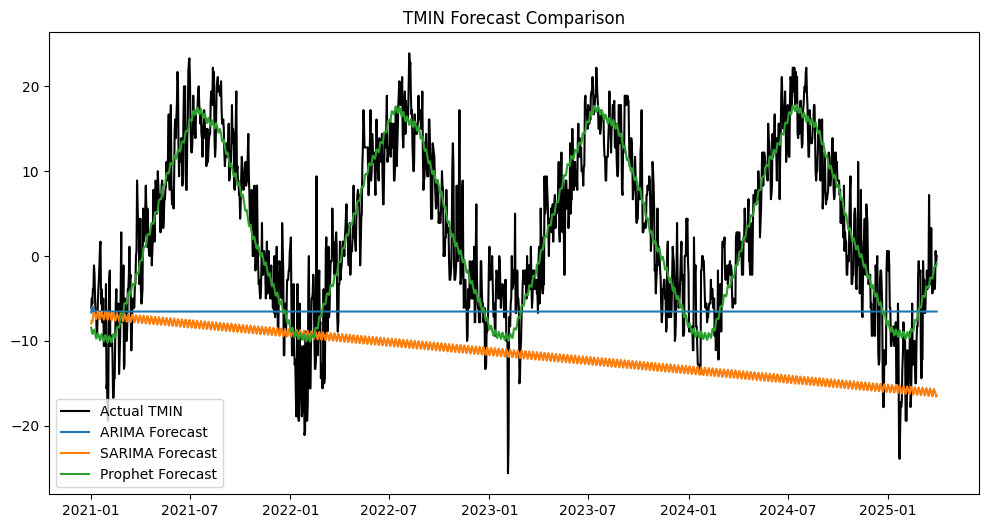

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.metrics import mean_absolute_error

# Ensure DATE is the index
station_df = station_df.sort_index()

# Train-Test Split: Before 2021 is train, from 2021 is test
train = station_df[station_df.index < "2021-01-01"]
test = station_df[station_df.index >= "2021-01-01"]

# Store predictions
forecast_results = {}

### 1️⃣ ARIMA MODEL
arima_model = ARIMA(train['TMIN'], order=(5,1,0))
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=len(test))
forecast_results['ARIMA'] = arima_forecast

### 2️⃣ SARIMA MODEL
sarima_model = SARIMAX(train['TMIN'], order=(1,1,1), seasonal_order=(1,1,1,7))
sarima_fit = sarima_model.fit()
sarima_forecast = sarima_fit.forecast(steps=len(test))
forecast_results['SARIMA'] = sarima_forecast

### 3️⃣ PROPHET MODEL
prophet_df = train[['TMIN']].reset_index().rename(columns={'DATE': 'ds', 'TMIN': 'y'})
prophet_model = Prophet()
prophet_model.fit(prophet_df)
future_dates = prophet_model.make_future_dataframe(periods=len(test))
prophet_forecast = prophet_model.predict(future_dates)['yhat'].iloc[-len(test):]
forecast_results['Prophet'] = prophet_forecast

# Evaluate and Compare Models
for model_name, predictions in forecast_results.items():
    error = mean_absolute_error(test['TMIN'], predictions)
    print(f"{model_name} MAE: {error:.2f}")

# Plot Results
plt.figure(figsize=(12,6))
plt.plot(test.index, test['TMIN'], label="Actual TMIN", color='black')
for model_name, predictions in forecast_results.items():
    plt.plot(test.index, predictions, label=f"{model_name} Forecast")
plt.legend()
plt.title("TMIN Forecast Comparison")
plt.show()


/usr/local/python/3.11.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/python/3.11.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA order (0, 0, 0) failed: Input contains NaN.


/usr/local/python/3.11.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/python/3.11.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/python/3.11.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA order (0, 0, 1) failed: Input contains NaN.


/usr/local/python/3.11.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/python/3.11.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/python/3.11.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/python/3.11.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/python/3.11.11/lib/python3.11/site-packag

SARIMA order (1, 0, 0) failed: Input contains NaN.


/usr/local/python/3.11.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA order (1, 0, 1) failed: Input contains NaN.


/usr/local/python/3.11.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/python/3.11.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
17:55:24 - cmdstanpy - INFO - Chain [1] start processing
17:55:29 - cmdstanpy - INFO - Chain [1] done processing


SARIMA Best Order: (1, 1, 1), MAPE: 37319.92%
Prophet MAPE: 2102371237487.17%


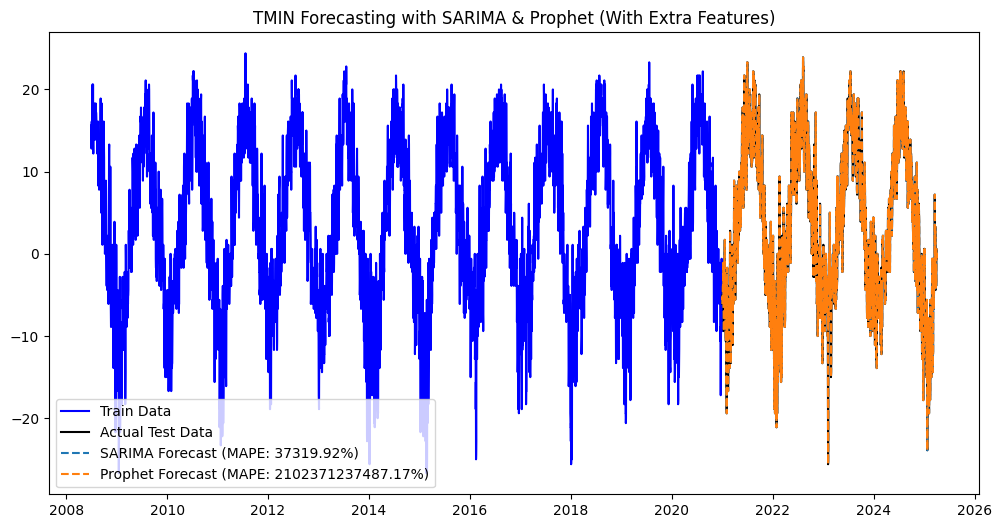

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit
from itertools import product

# Split Data
train = station_df.loc[:'2020-12-31']
test = station_df.loc['2021-01-01':]

# Features to use
exog_features = ['Rolling_Mean_TMIN_7', 'Rolling_10thPercentile_TMIN_7', 
                 'Seasonal_TMIN_Anomaly', 'EWMA_TMIN_7', 'TMIN_Lag1', 'TMIN_Rolling_30_Diff']

# Function to calculate MAPE (Percentage Accuracy)
def calculate_mape(y_true, y_pred):
    return np.round(mean_absolute_percentage_error(y_true, y_pred) * 100, 2)

# TimeSeriesSplit for Model Evaluation
tscv = TimeSeriesSplit(n_splits=3)

### SARIMA with Exogenous Features ###
P_values, D_values, Q_values = [0, 1], [0, 1], [0, 1]
best_sarima_mape, best_sarima_order = float("inf"), None

for P, D, Q in product(P_values, D_values, Q_values):
    try:
        temp_mape = []
        for train_idx, val_idx in tscv.split(train):
            train_fold, val_fold = train.iloc[train_idx], train.iloc[val_idx]
            model = SARIMAX(train_fold['TMIN'], exog=train_fold[exog_features], 
                            order=(1, 1, 1), seasonal_order=(P, D, Q, 12),
                            enforce_stationarity=False, enforce_invertibility=False)
            model_fit = model.fit(disp=False)
            forecast = model_fit.forecast(steps=len(val_fold), exog=val_fold[exog_features])
            temp_mape.append(calculate_mape(val_fold['TMIN'], forecast))
        
        avg_mape = np.mean(temp_mape)
        if avg_mape < best_sarima_mape:
            best_sarima_mape, best_sarima_order = avg_mape, (P, D, Q)
    except Exception as e:
        print(f"SARIMA order {P, D, Q} failed: {e}")
        continue

# Fit best SARIMA model
sarima_model = SARIMAX(train['TMIN'], exog=train[exog_features], 
                       order=(1, 1, 1), seasonal_order=(*best_sarima_order, 12),
                       enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)
sarima_forecast = sarima_fit.forecast(steps=len(test), exog=test[exog_features])
sarima_mape = calculate_mape(test['TMIN'], sarima_forecast)

### Prophet with Extra Features ###
prophet_df = train.reset_index()[['DATE', 'TMIN'] + exog_features].rename(columns={'DATE': 'ds', 'TMIN': 'y'})
prophet_model = Prophet()
for feature in exog_features:
    prophet_model.add_regressor(feature)

prophet_model.fit(prophet_df)
future = test.reset_index()[['DATE'] + exog_features].rename(columns={'DATE': 'ds'})
prophet_forecast = prophet_model.predict(future)['yhat'].values
prophet_mape = calculate_mape(test['TMIN'].values, prophet_forecast)

# Print Accuracy
print(f"SARIMA Best Order: {best_sarima_order}, MAPE: {sarima_mape}%")
print(f"Prophet MAPE: {prophet_mape}%")

# Plot Results
plt.figure(figsize=(12,6))
plt.plot(train.index, train['TMIN'], label="Train Data", color='blue')
plt.plot(test.index, test['TMIN'], label="Actual Test Data", color='black')
plt.plot(test.index, sarima_forecast, label=f"SARIMA Forecast (MAPE: {sarima_mape}%)", linestyle="dashed")
plt.plot(test.index, prophet_forecast, label=f"Prophet Forecast (MAPE: {prophet_mape}%)", linestyle="dashed")
plt.legend()
plt.title("TMIN Forecasting with SARIMA & Prophet (With Extra Features)")
plt.show()
